# Model — ตอบคำถามธุรกิจกลุ่ม B

โหลด **dataset #2 (พร้อมเทรนโมเดล)** จาก Hugging Face แล้วทำโมเดลตัวอย่าง 5 แบบ
ที่ครอบคลุมตระกูลหลัก:

| # | คำถาม | โมเดล |
|---|-------|-------|
| B2 | ข้อความในรีวิวตรงกับดาวที่ให้ไหม | **Classification** (TF-IDF + Logistic Regression) |
| B3 | สินค้าแบ่งได้กี่กลุ่มตาม performance | **Clustering** (K-Means) |
| B1 | สินค้าใหม่จะได้คะแนนเท่าไหร่ | **Regression** (Ridge เทียบ Gradient Boosting) |
| B4 | ลูกค้าบ่นเรื่องอะไรในรีวิวเชิงลบ | **Topic Modeling** (LDA) |
| B5 | รีวิวไหนน่าสงสัยว่าปลอม/จ้าง | **Anomaly Detection** (Isolation Forest + TF-IDF cosine) |

ทั้งหมดรันบน CPU ได้ ไม่ต้องใช้ GPU

**หลักที่ยึดทุกข้อ**
- ใช้ split ที่เตรียมมาแล้ว (`train`/`val`/`test`) — **ห้ามสุ่มแบ่งใหม่** เพราะจะกลายเป็น
  การทำนายอดีตจากอนาคต (data leakage)
- เทียบกับ **baseline** เสมอ ถ้าชนะ baseline ไม่ได้ต้องรายงานตามตรง
- คลาสไม่สมดุลหนัก → ใช้ `macro-F1` ไม่ใช่ `accuracy` และตั้ง `class_weight='balanced'`

In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "config.yaml").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

from elt.common import load_config, resolve_dataset  # noqa: E402

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# numpy ที่ลิงก์กับ Apple Accelerate BLAS (ค่าเริ่มต้นบน macOS) ปล่อย RuntimeWarning
# "divide by zero / overflow in matmul" ออกมาแบบผิด ๆ ตอน sklearn คูณเมทริกซ์
# ตรวจแล้วว่าข้อมูลไม่มี NaN/Inf และไม่มีคอลัมน์ variance = 0 จริง ๆ
# จึงปิด warning นี้เพื่อไม่ให้ผลลัพธ์อ่านยาก (ถ้าใช้ BLAS อื่นจะไม่เจอตั้งแต่แรก)
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

config = load_config()
SRC = resolve_dataset("preprocessing", config)

con = duckdb.connect()
con.execute(f"CREATE VIEW reviews AS SELECT * FROM '{SRC}/reviews/**/*.parquet'")
con.execute(f"CREATE VIEW product_features AS SELECT * FROM '{SRC}/product_features.parquet'")

# ที่เก็บผลลัพธ์ทุกโมเดล (metrics/mismatch/cluster) — data/ ถูก gitignore ไว้แล้ว
OUTPUT_DIR = ROOT / "data" / "model_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ที่เก็บตัวโมเดลที่เทรนแล้ว (joblib) — dashboard โหลดจากตรงนี้ ไม่ retrain สด
import joblib
MODEL_DIR = ROOT / "data" / "model_artifacts"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

con.sql("""
    SELECT split, count(*) AS n_reviews,
           min(review_date) AS first_date, max(review_date) AS last_date,
           round(avg(rating), 2) AS avg_rating
    FROM reviews GROUP BY 1 ORDER BY first_date
""").df()

/Users/madness/Desktop/KU/yr3/Product-Performance-Analytics-on-Marketplace-Data/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 1013.89it/s]

แหล่งข้อมูล: Hugging Face — Madnesss/amazon-beauty-analytics-ready


,split,n_reviews,first_date,last_date,avg_rating
0,train,2581670,2000-11-01,2020-12-31,3.98
1,val,467957,2021-01-01,2021-12-31,3.78
2,test,320143,2022-01-01,2023-09-11,3.77


## B2. ข้อความในรีวิวตรงกับดาวที่ให้ไหม? — Classification

**ทำไมต้องใช้โมเดล** — ต้องเข้าใจความหมายของข้อความ ไม่มีคอลัมน์ไหนบอกได้ว่า
รีวิวนี้ "น้ำเสียงบวกหรือลบ"

**ประโยชน์จริง** ไม่ได้อยู่ที่ค่า F1 แต่อยู่ที่การเอาโมเดลไปหา**รีวิวที่โมเดลมั่นใจว่าลบ
แต่ลูกค้าให้ 5 ดาว** (และกลับกัน) — กลุ่มนี้คือคนที่กดดาวผิด ประชด หรือให้ดาวตามของแถม
ซึ่งทำให้คะแนนสินค้าเพี้ยน

> สุ่มตัวอย่างจาก train เพื่อให้รันจบใน 1–2 นาทีบนโน้ตบุ๊ก
> ถ้าจะใช้จริงให้เอาออก หรือเปลี่ยนไป fine-tune DistilBERT

In [2]:
TRAIN_SAMPLE = 300_000        # ตั้ง None ถ้าอยากใช้ทั้งหมด (2.58M แถว)
TEST_SAMPLE = 100_000

def load_split(split, limit=None, cols="text_full, sentiment, rating, review_id, category"):
    q = f"SELECT {cols} FROM reviews WHERE split = '{split}'"
    if limit:
        q += f" USING SAMPLE {limit} ROWS (reservoir, {RANDOM_STATE})"
    return con.sql(q).df()

train = load_split("train", TRAIN_SAMPLE)
test  = load_split("test",  TEST_SAMPLE)
print(f"train {len(train):,} แถว | test {len(test):,} แถว")

dist = pd.DataFrame({
    "train": train.sentiment.value_counts(normalize=True),
    "test":  test.sentiment.value_counts(normalize=True),
}).round(3)
print("\nสัดส่วนคลาส — สังเกตว่า test มีรีวิวลบมากกว่า train (distribution shift ของจริง):")
dist

train 230,395 แถว | test 9,569 แถว

สัดส่วนคลาส — สังเกตว่า test มีรีวิวลบมากกว่า train (distribution shift ของจริง):


,train,test
sentiment,,
positive,0.713,0.650
negative,0.190,0.252
neutral,0.096,0.098


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import make_pipeline

clf = make_pipeline(
    TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), min_df=3, sublinear_tf=True),
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
)
clf.fit(train.text_full, train.sentiment)

pred = clf.predict(test.text_full)
print(classification_report(test.sentiment, pred, digits=3))

# baseline: ทายคลาสที่พบบ่อยที่สุดเสมอ — ถ้าโมเดลไม่ชนะอันนี้ก็ไม่มีประโยชน์
majority = train.sentiment.mode()[0]
base_f1 = f1_score(test.sentiment, [majority] * len(test), average="macro", zero_division=0)
model_f1 = f1_score(test.sentiment, pred, average="macro")
print(f"macro-F1  baseline (ทาย '{majority}' เสมอ): {base_f1:.3f}")
print(f"macro-F1  โมเดล:                        {model_f1:.3f}")
print(f"→ ดีขึ้น {model_f1 - base_f1:+.3f}")

b2_path = MODEL_DIR / "b2_sentiment_classifier.joblib"
joblib.dump({"pipeline": clf, "labels": list(clf.classes_),
             "macro_f1_test": model_f1, "baseline_macro_f1": base_f1}, b2_path)
print(f"บันทึกโมเดล B2 -> {b2_path.relative_to(ROOT)}")

              precision    recall  f1-score   support

    negative      0.789     0.809     0.799      2413
     neutral      0.324     0.527     0.401       938
    positive      0.967     0.865     0.913      6218

    accuracy                          0.818      9569
   macro avg      0.693     0.734     0.704      9569
weighted avg      0.859     0.818     0.834      9569

macro-F1  baseline (ทาย 'positive' เสมอ): 0.263
macro-F1  โมเดล:                        0.704
→ ดีขึ้น +0.442


บันทึกโมเดล B2 -> data/model_artifacts/b2_sentiment_classifier.joblib


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2269357080.py:13: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2269357080.py:13: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2269357080.py:13: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2269357080.py:13: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ip

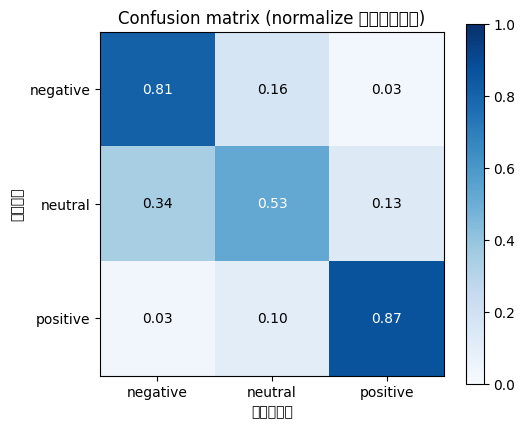

neutral (3 ดาว) มักถูกทายผิดที่สุด — เป็นเรื่องปกติ
เพราะข้อความ 3 ดาวมีทั้งคำชมและคำติปนกัน ขอบเขตจึงคลุมเครือโดยธรรมชาติ


In [4]:
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(test.sentiment, pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(3), labels); ax.set_yticks(range(3), labels)
ax.set_xlabel("ทำนาย"); ax.set_ylabel("จริง")
ax.set_title("Confusion matrix (normalize ตามแถว)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black")
ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()

print("neutral (3 ดาว) มักถูกทายผิดที่สุด — เป็นเรื่องปกติ")
print("เพราะข้อความ 3 ดาวมีทั้งคำชมและคำติปนกัน ขอบเขตจึงคลุมเครือโดยธรรมชาติ")

In [5]:
# ── ประโยชน์ทางธุรกิจที่แท้จริงของข้อนี้ ──
# หารีวิวที่โมเดลมั่นใจมากว่า "ลบ" แต่ลูกค้าให้ 5 ดาว (และกลับกัน: "บวก" แต่ให้ 1 ดาว)
proba = clf.predict_proba(test.text_full)
neg_idx = list(clf.classes_).index("negative")
pos_idx = list(clf.classes_).index("positive")

test = test.assign(p_negative=proba[:, neg_idx], p_positive=proba[:, pos_idx])

mismatch_neg = test[(test.rating == 5) & (test.p_negative > 0.9)].assign(
    mismatch_type="5-star rated as negative")
mismatch_pos = test[(test.rating == 1) & (test.p_positive > 0.9)].assign(
    mismatch_type="1-star rated as positive")
mismatch = pd.concat([mismatch_neg, mismatch_pos], ignore_index=True)

print(f"5 ดาวที่โมเดลมั่นใจ >90% ว่าลบ: {len(mismatch_neg):,} จาก {len(test):,} แถว")
print(f"1 ดาวที่โมเดลมั่นใจ >90% ว่าบวก: {len(mismatch_pos):,} จาก {len(test):,} แถว\n")

print("ตัวอย่าง 5 ดาวที่โมเดลทายว่าลบ:")
for _, r in mismatch_neg.nlargest(5, "p_negative").iterrows():
    print(f"  [{r.p_negative:.0%} ลบ | ให้ {int(r.rating)} ดาว] {r.text_full[:150]}...")

print("\nตัวอย่าง 1 ดาวที่โมเดลทายว่าบวก:")
for _, r in mismatch_pos.nlargest(5, "p_positive").iterrows():
    print(f"  [{r.p_positive:.0%} บวก | ให้ {int(r.rating)} ดาว] {r.text_full[:150]}...")

mismatch_path = OUTPUT_DIR / "b2_mismatch_reviews.csv"
mismatch[["review_id", "category", "rating", "mismatch_type",
          "p_negative", "p_positive", "text_full"]].to_csv(mismatch_path, index=False)
print(f"\nบันทึกรีวิวที่ดาวไม่ตรงข้อความทั้งหมด ({len(mismatch):,} แถว) -> {mismatch_path.relative_to(ROOT)}")

5 ดาวที่โมเดลมั่นใจ >90% ว่าลบ: 5 จาก 9,569 แถว
1 ดาวที่โมเดลมั่นใจ >90% ว่าบวก: 1 จาก 9,569 แถว

ตัวอย่าง 5 ดาวที่โมเดลทายว่าลบ:
  [97% ลบ | ให้ 5 ดาว] I am not happy My order had a problem one of my perms was leaking everything was a mess. Dislike my permanent waves were leaking it was awful 😖...
  [94% ลบ | ให้ 5 ดาว] Overpriced by 10 fold. Please - do yourself a favor and do not pay more than 30 bucks for this watch. Daniel Wellington is a terrible brand in terms o...
  [93% ลบ | ให้ 5 ดาว] clipper blade. already have clippers-that attachment broke....
  [91% ลบ | ให้ 5 ดาว] Broken. I have baught 2 of these at different times the first one was great the one I just received today was broke one of the antlers was completely ...
  [90% ลบ | ให้ 5 ดาว] Not as pictured. The hair is very short at the top. You can not pull it in a ponytail. It’s so thick. That’s what I could have done if it was all the ...

ตัวอย่าง 1 ดาวที่โมเดลทายว่าบวก:
  [95% บวก | ให้ 1 ดาว] Great product. It really 

## B3. สินค้าแบ่งได้เป็นกี่กลุ่มตามลักษณะ performance? — Clustering

**ทำไมต้องใช้โมเดล** — เราไม่รู้ล่วงหน้าว่ามีกี่กลุ่มและแบ่งด้วยเกณฑ์อะไร
ถ้าตั้งกฎเอง (เช่น "คะแนน > 4 = ดี") ก็แค่ยัดความเชื่อของเราลงไป

**สิ่งที่ต้องทำก่อนเสมอ** — standardize เพราะ K-Means ไวต่อสเกลมาก
ถ้าไม่ทำ `n_reviews` (หลักพัน) จะกลบ `avg_rating` (หลักหน่วย) จนคลัสเตอร์ไร้ความหมาย

In [6]:
# ตัดสินค้าที่รีวิวน้อยออก เพราะสถิติยังไม่นิ่ง (คะแนนเฉลี่ยจาก 2 รีวิวเชื่อไม่ได้)
MIN_REVIEWS = 20

prod = con.sql(f"""
    SELECT product_key, parent_asin, category, product_title, store, price_band,
           n_reviews, avg_rating, rating_std, negative_share,
           polarized_share, verified_share, review_span_days
    FROM product_features
    WHERE n_reviews >= {MIN_REVIEWS} AND rating_std IS NOT NULL
""").df()
print(f"สินค้าที่เข้าเกณฑ์: {len(prod):,} จากทั้งหมด "
      f"{con.execute('SELECT count(*) FROM product_features').fetchone()[0]:,}")

FEATURES = ["avg_rating", "rating_std", "negative_share",
            "polarized_share", "verified_share", "review_span_days"]
X = prod[FEATURES].copy()
X["n_reviews_log"] = np.log1p(prod.n_reviews)   # เบ้ขวาหนัก ต้อง log ก่อน
X.describe().round(3)

สินค้าที่เข้าเกณฑ์: 23,101 จากทั้งหมด 998,708


,avg_rating,rating_std,negative_share,polarized_share,verified_share,review_span_days,n_reviews_log
count,23101.000,23101.000,23101.000,23101.000,23101.000,23101.000,23101.000
mean,4.014,1.267,0.185,0.717,0.927,1331.909,3.723
std,0.605,0.343,0.151,0.126,0.135,890.087,0.676
min,1.050,0.000,0.000,0.120,0.000,29.000,3.045
25%,3.704,1.054,0.077,0.636,0.924,699.000,3.219
50%,4.132,1.313,0.148,0.725,0.967,1123.000,3.526
75%,4.455,1.529,0.250,0.810,1.000,1746.000,4.007
max,5.000,2.027,1.000,1.000,1.000,7549.000,8.920


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2181689672.py:20: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2181689672.py:20: UserWarning: Glyph 3641 (\N{THAI CHARACTER SARA UU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2181689672.py:20: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2181689672.py:20: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/2181689672.py:20: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

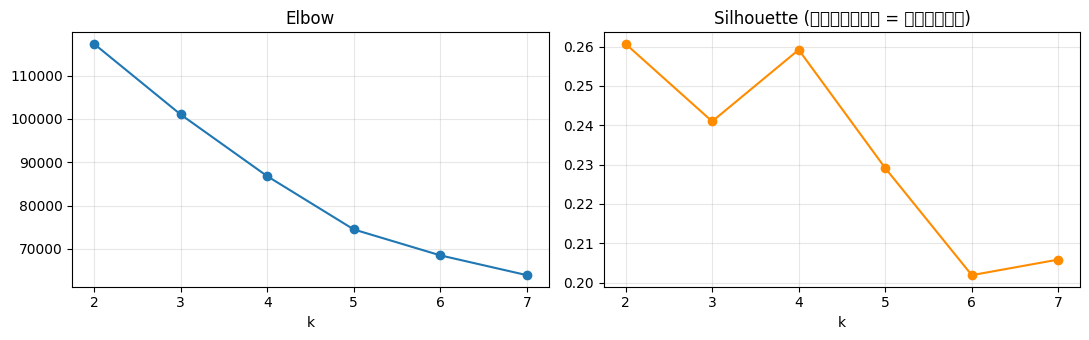

,k,inertia,silhouette
0,2,117316.563,0.261
1,3,101018.676,0.241
2,4,86778.068,0.259
3,5,74479.955,0.229
4,6,68492.901,0.202
5,7,63923.731,0.206


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# เลือก k ด้วย elbow + silhouette (silhouette คำนวณบน subsample เพื่อความเร็ว)
sub = np.random.choice(len(Xs), min(10_000, len(Xs)), replace=False)
scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
    scores.append((k, km.inertia_, silhouette_score(Xs[sub], km.labels_[sub])))

sc = pd.DataFrame(scores, columns=["k", "inertia", "silhouette"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(sc.k, sc.inertia, marker="o"); ax1.set_title("Elbow"); ax1.set_xlabel("k")
ax2.plot(sc.k, sc.silhouette, marker="o", color="darkorange")
ax2.set_title("Silhouette (สูงกว่า = ดีกว่า)"); ax2.set_xlabel("k")
plt.tight_layout(); plt.show()
sc.round(3)

In [8]:
# เลือก K จาก silhouette สูงสุด (คำนวณไว้แล้วใน sc ด้านบน) แทนการเดาด้วยตา
K = int(sc.loc[sc.silhouette.idxmax(), "k"])
print(f"เลือก K={K} จาก silhouette สูงสุด ({sc.silhouette.max():.3f})")

km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(Xs)
prod["cluster"] = km.labels_

profile = prod.groupby("cluster").agg(
    n_products=("product_key", "size"),
    avg_rating=("avg_rating", "mean"),
    rating_std=("rating_std", "mean"),
    negative_share=("negative_share", "mean"),
    polarized_share=("polarized_share", "mean"),
    verified_share=("verified_share", "mean"),
    median_reviews=("n_reviews", "median"),
).round(3)

# ตั้งชื่อกลุ่มแบบ rule-based จากลักษณะเด่น — generic กับ K เท่าไหร่ก็ได้ ไม่ผูกกับ K=4 ตายตัว
names = {}
remaining = list(profile.index)

worst = profile.loc[remaining, "negative_share"].idxmax()
names[worst] = "ต้องเข้าไปแก้ด่วน"
remaining.remove(worst)

if remaining:
    stable = profile.loc[remaining]
    stable = stable[stable.rating_std < profile.rating_std.median()]
    if len(stable):
        best = stable.avg_rating.idxmax()
        names[best] = "ดาวเด่นมั่นคง"
        remaining.remove(best)

if remaining:
    polarized = profile.loc[remaining, "polarized_share"].idxmax()
    names[polarized] = "แตกขั้ว (ความคาดหวังไม่ตรง)"
    remaining.remove(polarized)

if remaining:
    newest = profile.loc[remaining, "median_reviews"].idxmin()
    names[newest] = "ยังใหม่ ข้อมูลไม่พอตัดสิน"
    remaining.remove(newest)

for i, c in enumerate(remaining, 1):
    names[c] = f"กลุ่มกลาง {i}"

profile["cluster_name"] = profile.index.map(names)
prod["cluster_name"] = prod.cluster.map(names)
display(profile)

b3_path = MODEL_DIR / "b3_kmeans.joblib"
joblib.dump({"scaler": scaler, "kmeans": km, "features": FEATURES,
             "k": K, "cluster_names": names}, b3_path)
print(f"บันทึกโมเดล B3 -> {b3_path.relative_to(ROOT)}")

เลือก K=2 จาก silhouette สูงสุด (0.261)


,n_products,avg_rating,rating_std,negative_share,polarized_share,verified_share,median_reviews,cluster_name
cluster,,,,,,,,
0,10014,3.477,1.544,0.313,0.647,0.937,32.0,ต้องเข้าไปแก้ด่วน
1,13087,4.425,1.054,0.087,0.771,0.920,34.0,ดาวเด่นมั่นคง


บันทึกโมเดล B3 -> data/model_artifacts/b3_kmeans.joblib


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3052338954.py:10: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3052338954.py:10: UserWarning: Glyph 3632 (\N{THAI CHARACTER SARA A}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3052338954.py:10: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3052338954.py:10: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3052338954.py:10: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

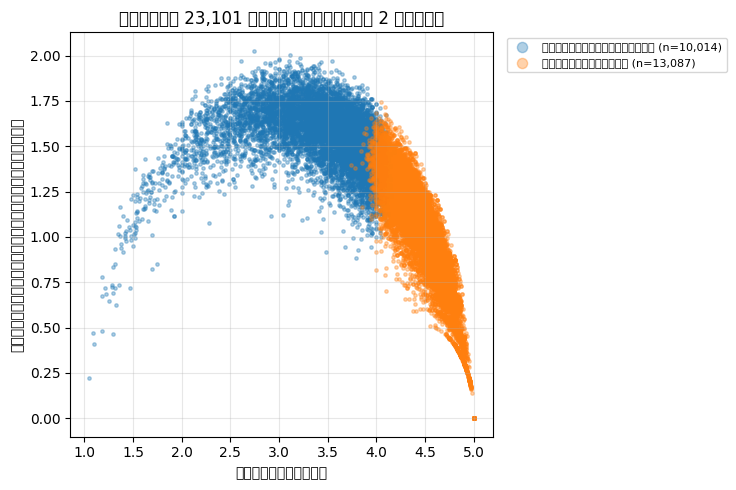

ตัวอย่างสินค้าในแต่ละกลุ่ม:
  ต้องเข้าไปแก้ด่วน            | 3.83⭐ sd=1.45 4055 รีวิว | NELEUS Women's 3 Pack Compression Base Layer 
  ดาวเด่นมั่นคง                | 4.41⭐ sd=1.12 7480 รีวิว | Casio F91W-1 Classic Resin Strap Digital Spor



บันทึก cluster profile -> data/model_output/b3_cluster_profile.csv
บันทึก product-level cluster assignment -> data/model_output/b3_product_clusters.parquet


In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5))
cmap = plt.get_cmap("tab10")
for i, c in enumerate(sorted(prod.cluster.unique())):
    sub = prod[prod.cluster == c]
    ax.scatter(sub.avg_rating, sub.rating_std, s=6, alpha=0.35,
               color=cmap(i), label=f"{names[c]} (n={len(sub):,})")
ax.set_xlabel("คะแนนเฉลี่ย"); ax.set_ylabel("ส่วนเบี่ยงเบนมาตรฐานของคะแนน")
ax.set_title(f"สินค้า {len(prod):,} ชิ้น แบ่งเป็น {K} กลุ่ม")
ax.legend(markerscale=3, fontsize=8, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

print("ตัวอย่างสินค้าในแต่ละกลุ่ม:")
for c in sorted(prod.cluster.unique()):
    r = prod[prod.cluster == c].nlargest(1, "n_reviews").iloc[0]
    print(f"  {names[c]:<28} | {r.avg_rating:.2f}⭐ sd={r.rating_std:.2f} "
          f"{r.n_reviews:>4} รีวิว | {str(r.product_title)[:45]}")

profile_path = OUTPUT_DIR / "b3_cluster_profile.csv"
profile.to_csv(profile_path)
clusters_path = OUTPUT_DIR / "b3_product_clusters.parquet"
prod[["product_key", "parent_asin", "category", "cluster", "cluster_name"]].to_parquet(
    clusters_path, index=False)
print(f"\nบันทึก cluster profile -> {profile_path.relative_to(ROOT)}")
print(f"บันทึก product-level cluster assignment -> {clusters_path.relative_to(ROOT)}")

## B1. สินค้าใหม่จะได้คะแนนเท่าไหร่? — Regression

**ทำไมต้องใช้โมเดล** — สินค้าใหม่ยัง**ไม่มีรีวิวเลย** จะ `GROUP BY` หาค่าเฉลี่ยของมันไม่ได้
ต้องเรียนรู้ความสัมพันธ์จากสินค้าที่มีอยู่แล้ว

⚠️ **สองกับดักที่ต้องระวัง**
1. **แบ่งตามเวลา** ด้วย `first_review_date` ไม่ใช่สุ่ม — ไม่งั้นคือทำนายอดีตจากอนาคต
2. **ห้ามใช้** `avg_rating` ของตัวเองหรือ `listed_avg_rating` เป็น feature — นั่นคือคำตอบ

In [10]:
# โหลด dim_product จาก dataset #1 (ELT stage) เพื่อดึง listed_rating_count มาเป็น feature
# (ไม่ได้อยู่ใน product_features.parquet ของ dataset #2 — ดู docs/business_questions.md B1)
ELT_SRC = resolve_dataset("elt", config)
con.execute(f"CREATE VIEW dim_product_elt AS SELECT * FROM '{ELT_SRC}/dim_product.parquet'")

# ใช้เฉพาะสินค้าที่รู้ราคา (feature หลัก) และมีรีวิวพอให้ target นิ่ง
reg = con.sql("""
    SELECT pf.category, pf.store, pf.price, pf.price_band, pf.n_reviews,
           pf.first_review_date, pf.avg_rating, dp.listed_rating_count
    FROM product_features pf
    LEFT JOIN dim_product_elt dp USING (product_key)
    WHERE pf.price IS NOT NULL AND pf.n_reviews >= 20
""").df()

# แบ่งตามเวลา: สินค้าที่เปิดตัวก่อน 2019 = train, ตั้งแต่ 2019 = test
cutoff = pd.Timestamp("2019-01-01")
reg["first_review_date"] = pd.to_datetime(reg.first_review_date)
tr, te = reg[reg.first_review_date < cutoff], reg[reg.first_review_date >= cutoff]
print(f"train {len(tr):,} สินค้า (เปิดตัวก่อน 2019) | test {len(te):,} สินค้า (2019+)")

# encode แบรนด์ด้วยความถี่ ไม่ใช่ target encoding เพราะ target encoding รั่วง่าย
freq = tr.store.value_counts()

def featurize(df):
    out = pd.DataFrame(index=df.index)
    out["price_log"] = np.log1p(df.price)
    out["store_freq"] = df.store.map(freq).fillna(0)
    out["listed_rating_count_log"] = np.log1p(df.listed_rating_count.fillna(0))
    for c in sorted(reg.category.unique()):
        out[f"cat_{c}"] = (df.category == c).astype(int)
    for b in sorted(reg.price_band.unique()):
        out[f"band_{b}"] = (df.price_band == b).astype(int)
    return out

Xtr, ytr = featurize(tr), tr.avg_rating
Xte, yte = featurize(te), te.avg_rating
print(f"feature: {Xtr.shape[1]} คอลัมน์")

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Fetching 12 files: 100%|██████████| 12/12 [00:00<00:00, 2079.73it/s]

แหล่งข้อมูล: Hugging Face — Madnesss/amazon-beauty-star-schema
train 3,899 สินค้า (เปิดตัวก่อน 2019) | test 2,056 สินค้า (2019+)
feature: 11 คอลัมน์


In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def rmse(y, p):
    return mean_squared_error(y, p) ** 0.5

results = []
# baseline ที่ต้องเอาชนะให้ได้: ทายค่าเฉลี่ยของ "หมวด" เสมอ (ตาม docs/business_questions.md B1)
# ไม่ใช่ค่าเฉลี่ยรวมทั้งชุด — หมวดที่ไม่เคยเห็นใน train (ถ้ามี) ใช้ค่าเฉลี่ยรวมแทน
cat_means = tr.groupby("category").avg_rating.mean()
baseline_pred = te.category.map(cat_means).fillna(ytr.mean())
results.append(("Baseline (ทายค่าเฉลี่ยของหมวด)",
                mean_absolute_error(yte, baseline_pred),
                rmse(yte, baseline_pred),
                r2_score(yte, baseline_pred)))

fitted_models = {}
for name, model in [("Ridge", Ridge(alpha=1.0)),
                    ("GradientBoosting", HistGradientBoostingRegressor(
                        random_state=RANDOM_STATE, max_iter=200))]:
    model.fit(Xtr, ytr)
    fitted_models[name] = model
    p = model.predict(Xte)
    results.append((name, mean_absolute_error(yte, p), rmse(yte, p), r2_score(yte, p)))

res = pd.DataFrame(results, columns=["model", "MAE", "RMSE", "R2"]).round(4)
display(res)

best = res.iloc[1:].nsmallest(1, "MAE").iloc[0]
gain = res.MAE.iloc[0] - best.MAE
print(f"โมเดลดีที่สุด: {best.model}  MAE {best.MAE:.4f}  RMSE {best.RMSE:.4f}")
print(f"ดีกว่า baseline {gain:.4f} ดาว ({gain / res.MAE.iloc[0]:.1%})")
if gain < 0.01:
    print("\n→ แทบไม่ชนะ baseline: ราคา+แบรนด์+หมวด อธิบายคะแนนได้น้อยมาก")
    print("  ต้องรายงานตามตรง และถ้าจะทำต่อควรเพิ่ม feature จากข้อความรายละเอียดสินค้า")

res_path = OUTPUT_DIR / "b1_regression_metrics.json"
res.to_json(res_path, orient="records", force_ascii=False, indent=2)
print(f"\nบันทึก regression metrics -> {res_path.relative_to(ROOT)}")

b1_path = MODEL_DIR / "b1_regression_models.joblib"
joblib.dump({"ridge": fitted_models["Ridge"], "gbm": fitted_models["GradientBoosting"],
             "feature_columns": list(Xtr.columns), "category_baseline_means": cat_means,
             "overall_mean": ytr.mean(), "metrics": res}, b1_path)
print(f"บันทึกโมเดล B1 -> {b1_path.relative_to(ROOT)}")

,model,MAE,RMSE,R2
0,Baseline (ทายค่าเฉลี่ยของหมวด),0.4533,0.6061,-0.0319
1,Ridge,0.4543,0.6108,-0.0482
2,GradientBoosting,0.4744,0.6175,-0.0711


โมเดลดีที่สุด: Ridge  MAE 0.4543  RMSE 0.6108
ดีกว่า baseline -0.0010 ดาว (-0.2%)

→ แทบไม่ชนะ baseline: ราคา+แบรนด์+หมวด อธิบายคะแนนได้น้อยมาก
  ต้องรายงานตามตรง และถ้าจะทำต่อควรเพิ่ม feature จากข้อความรายละเอียดสินค้า

บันทึก regression metrics -> data/model_output/b1_regression_metrics.json
บันทึกโมเดล B1 -> data/model_artifacts/b1_regression_models.joblib


/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3243692828.py:14: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3243692828.py:14: UserWarning: Glyph 3635 (\N{THAI CHARACTER SARA AM}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3243692828.py:14: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3243692828.py:14: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/vn/_y1rl4y52sb3kx0xf36z3zv40000gn/T/ipykernel_31528/3243692828.py:14: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout

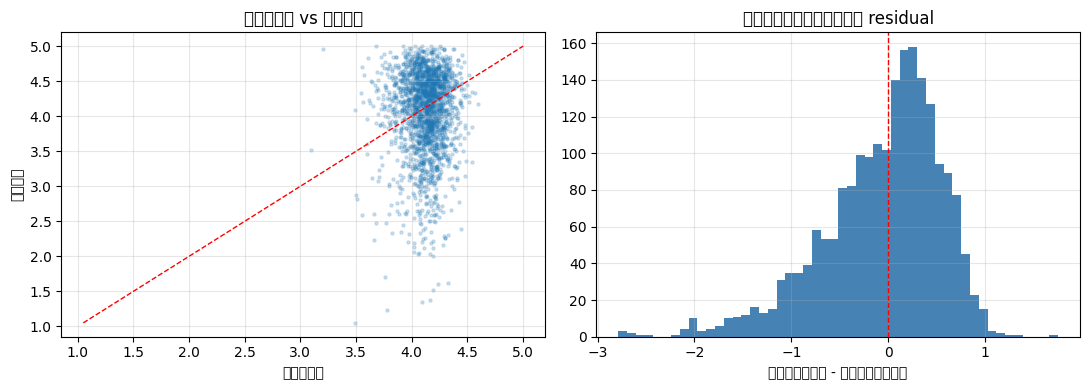

ถ้าจุดกระจุกเป็นแนวนอน (ทำนายค่าใกล้เคียงกันหมด) แปลว่าโมเดลแทบไม่ได้เรียนรู้อะไร
ซึ่งเป็นผลลัพธ์ที่ถูกต้องและต้องรายงาน ไม่ใช่ความผิดพลาด


In [12]:
# ใช้โมเดลที่เทรนไว้แล้วจาก cell ก่อนหน้า (fitted_models) แทนการ fit ซ้ำ
best_model = fitted_models["GradientBoosting"]
pred_te = best_model.predict(Xte)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(pred_te, yte, s=5, alpha=0.2)
lim = [min(pred_te.min(), yte.min()), max(pred_te.max(), yte.max())]
ax1.plot(lim, lim, "r--", lw=1)
ax1.set_xlabel("ทำนาย"); ax1.set_ylabel("จริง"); ax1.set_title("ทำนาย vs จริง")

ax2.hist(yte - pred_te, bins=50, color="steelblue")
ax2.axvline(0, color="red", ls="--", lw=1)
ax2.set_xlabel("ค่าจริง - ค่าทำนาย"); ax2.set_title("การกระจายของ residual")
plt.tight_layout(); plt.show()

print("ถ้าจุดกระจุกเป็นแนวนอน (ทำนายค่าใกล้เคียงกันหมด) แปลว่าโมเดลแทบไม่ได้เรียนรู้อะไร")
print("ซึ่งเป็นผลลัพธ์ที่ถูกต้องและต้องรายงาน ไม่ใช่ความผิดพลาด")

## B4. ลูกค้าบ่นเรื่องอะไรบ้างในรีวิวเชิงลบ และแต่ละหมวดบ่นต่างกันไหม? — Topic Modeling

**ทำไมต้องใช้โมเดล** — รู้ว่ารีวิว 1–2 ดาวคือ "ไม่พอใจ" แต่ไม่รู้ว่าไม่พอใจเรื่องอะไร
คำตอบอยู่ในข้อความล้วน ๆ มีเป็นแสนรีวิว อ่านเองไม่ไหว ต้องให้โมเดลจัดกลุ่มหัวข้อให้

> ใช้ **LDA** (ไม่ใช่ BERTopic) เพื่อไม่ต้องเพิ่ม dependency หนัก (bertopic/umap-learn/
> hdbscan/sentence-transformers) และรันบน CPU ได้เร็วพอสำหรับ notebook ตัวอย่าง —
> ถ้าต้องการคุณภาพ topic ที่ดีกว่าให้เปลี่ยนไปใช้ BERTopic แทน

**ระวัง** — topic ที่ได้ขึ้นกับ random seed ต้อง fix seed ไว้ (ทำแล้วด้วย `RANDOM_STATE`)
และต้องประเมินคุณภาพด้วยคน (อ่านตัวอย่างรีวิวจริงต่อ topic) ไม่ใช่ดูแค่คำที่โผล่มา

In [13]:
# ข้อมูล: รีวิวเชิงลบเท่านั้น จาก split train (คงกติกา "ใช้ split ที่เตรียมมาแล้ว")
# สุ่มตัวอย่างเพราะ LDA fit บน CPU ช้าขึ้นเป็นเส้นตรงตามจำนวนแถว/ขนาด vocabulary
B4_SAMPLE = 50_000

negative = con.sql(f"""
    SELECT review_id, category, review_year, text_full
    FROM reviews
    WHERE split = 'train' AND is_negative = true
    USING SAMPLE {B4_SAMPLE} ROWS (reservoir, {RANDOM_STATE})
""").df()
print(f"รีวิวเชิงลบที่สุ่มมา: {len(negative):,} แถว")
negative.category.value_counts()

รีวิวเชิงลบที่สุ่มมา: 7,219 แถว


category
Amazon_Fashion              4953
All_Beauty                  1324
Health_and_Personal_Care     942
Name: count, dtype: int64

In [14]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# LDA ใช้ raw term counts ไม่ใช่ TF-IDF ตาม convention มาตรฐาน
count_vec = CountVectorizer(max_features=5_000, min_df=5, max_df=0.5, stop_words="english")
Xcount = count_vec.fit_transform(negative.text_full)
vocab = count_vec.get_feature_names_out()

# จำนวน topic ตั้งเป็นค่าคงที่ ไม่ auto-search เหมือน B3 (K-Means) เพราะ fit LDA
# แพงกว่ามาก การ loop หลายค่า n_components บน CPU จะช้าเกินไปสำหรับ notebook ตัวอย่าง
# ถ้าจะทำจริงควรลอง sweep n_components แล้วดู lda.score() (log-likelihood) ประกอบ
N_TOPICS = 8
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE,
                                learning_method="online")
doc_topic = lda.fit_transform(Xcount)

negative["dominant_topic"] = doc_topic.argmax(axis=1)
negative["topic_prob"] = doc_topic.max(axis=1)

print(f"fit LDA เสร็จ — {N_TOPICS} topics บนคำศัพท์ {len(vocab):,} คำ")
negative.dominant_topic.value_counts().sort_index()

fit LDA เสร็จ — 8 topics บนคำศัพท์ 2,500 คำ


dominant_topic
0     556
1     454
2    1348
3     184
4    1110
5    1266
6    1098
7    1203
Name: count, dtype: int64

In [15]:
# top คำต่อ topic — ให้คนอ่านตั้งชื่อ topic เอง (ประเมินคุณภาพด้วยคน ไม่ใช่ดูคะแนนอย่างเดียว)
TOP_WORDS = 15
topic_words = []
for t in range(N_TOPICS):
    top_idx = lda.components_[t].argsort()[::-1][:TOP_WORDS]
    words = [vocab[i] for i in top_idx]
    topic_words.append(words)
    print(f"Topic {t}: {', '.join(words)}")

# docs/business_questions.md แนะนำอ่าน 10-20 รีวิวต่อ topic ก่อนประเมินคุณภาพ
EXAMPLES_PER_TOPIC = 10
print(f"\nตัวอย่างรีวิวจริงต่อ topic ({EXAMPLES_PER_TOPIC} รีวิว/topic — ดูของจริงประกอบคำ ไม่ใช่ดูแค่คำ):")
for t in range(N_TOPICS):
    sample = negative[negative.dominant_topic == t].nlargest(EXAMPLES_PER_TOPIC, "topic_prob")
    print(f"\n-- Topic {t} --")
    for _, r in sample.iterrows():
        print(f"  [{r.category} | {r.topic_prob:.0%}] {r.text_full[:150]}...")

# เทียบสัดส่วน topic ข้ามหมวด — คาดว่า Amazon_Fashion เด่นเรื่องไซซ์/ความพอดี
# ส่วน All_Beauty เด่นเรื่องอาการแพ้/กลิ่น/ของปลอม
category_share = pd.crosstab(negative.category, negative.dominant_topic, normalize="index").round(3)
display(category_share)

# เทียบสัดส่วน topic ตามปี — ดูว่า topic ไหนโตขึ้นตามเวลา (สัญญาณปัญหาใหม่)
yearly_share = pd.crosstab(negative.review_year, negative.dominant_topic, normalize="index").round(3)
display(yearly_share)

topic_words_df = pd.DataFrame(
    [(t, rank, w) for t, words in enumerate(topic_words) for rank, w in enumerate(words, 1)],
    columns=["topic_id", "rank", "word"])
topic_words_df.to_csv(OUTPUT_DIR / "b4_topic_words.csv", index=False)

negative[["review_id", "category", "review_year", "dominant_topic", "topic_prob"]].to_parquet(
    OUTPUT_DIR / "b4_review_topics.parquet", index=False)

category_share.to_csv(OUTPUT_DIR / "b4_category_topic_share.csv")
yearly_share.to_csv(OUTPUT_DIR / "b4_yearly_topic_share.csv")
print(f"\nบันทึกผลลัพธ์ B4 ทั้งหมด -> {OUTPUT_DIR.relative_to(ROOT)}/b4_*")

b4_path = MODEL_DIR / "b4_lda.joblib"
joblib.dump({"vectorizer": count_vec, "lda": lda, "n_topics": N_TOPICS,
             "topic_words": topic_words}, b4_path)
print(f"บันทึกโมเดล B4 -> {b4_path.relative_to(ROOT)}")

Topic 0: hair, big, long, expected, short, hard, use, recommend, really, way, times, good, weeks, just, item
Topic 1: quality, poor, did, shirt, bad, terrible, extremely, star, returned, isn, good, socks, bottle, case, instead
Topic 2: like, just, don, didn, did, nice, work, really, great, product, pretty, wanted, smell, doesn, use
Topic 3: cheaply, working, wash, shoe, years, break, stopped, dry, shape, pink, hot, gift, son, polish, nail
Topic 4: small, size, fit, way, large, ordered, wear, super, tight, fits, sizes, runs, order, smaller, cute
Topic 5: broke, time, came, quality, day, cheap, apart, use, worth, fell, great, buy, price, days, week
Topic 6: like, cheap, looks, dress, picture, color, material, look, fabric, received, disappointed, looked, looking, light, different
Topic 7: product, money, waste, don, work, broken, ve, better, star, does, disappointed, time, received, used, arrived

ตัวอย่างรีวิวจริงต่อ topic (10 รีวิว/topic — ดูของจริงประกอบคำ ไม่ใช่ดูแค่คำ):

-- Topic 0 

dominant_topic,0,1,2,3,4,5,6,7
category,,,,,,,,
All_Beauty,0.119,0.063,0.241,0.044,0.023,0.146,0.100,0.264
Amazon_Fashion,0.062,0.063,0.156,0.019,0.211,0.188,0.184,0.117
Health_and_Personal_Care,0.098,0.061,0.272,0.035,0.039,0.151,0.056,0.289


dominant_topic,0,1,2,3,4,5,6,7
review_year,,,,,,,,
2004,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000
2006,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
2007,0.091,0.000,0.273,0.000,0.000,0.091,0.182,0.364
2008,0.000,0.000,0.200,0.000,0.000,0.400,0.200,0.200
2009,0.000,0.333,0.333,0.000,0.000,0.000,0.000,0.333
2010,0.143,0.000,0.429,0.000,0.000,0.143,0.000,0.286
2011,0.222,0.000,0.278,0.000,0.167,0.000,0.056,0.278
2012,0.037,0.037,0.407,0.037,0.037,0.148,0.074,0.222
2013,0.104,0.052,0.208,0.010,0.083,0.198,0.146,0.198



บันทึกผลลัพธ์ B4 ทั้งหมด -> data/model_output/b4_*
บันทึกโมเดล B4 -> data/model_artifacts/b4_lda.joblib


## B5. รีวิวไหนน่าสงสัยว่าเป็นรีวิวปลอมหรือรีวิวจ้าง? — Anomaly Detection

**ทำไมต้องใช้โมเดล** — ไม่มีเฉลยว่ารีวิวไหนปลอม (ไม่มี label) และ "ความน่าสงสัย" ไม่ใช่
เงื่อนไขเดียวแต่เป็นรูปแบบร่วมของหลายสัญญาณ — เขียนเป็น `WHERE` ไม่ได้

**สัญญาณที่ใช้**: ไม่ verified purchase, ผู้รีวิวรีวิวครั้งเดียว (`One-off`), ประวัติผู้รีวิว
สั้น, คะแนนเบี่ยงจากค่าเฉลี่ยสินค้ามาก, ข้อความสั้นผิดปกติ, ข้อความคล้ายรีวิวอื่นมาก
(TF-IDF cosine แทน MinHash), รีวิวกระจุกตัวในช่วงเวลาสั้นของสินค้าเดียวกัน (burstiness)

> ผลลัพธ์คือ **"น่าสงสัย" ไม่ใช่ "ปลอมแน่นอน"** — ใช้ได้แค่เป็นการคัดกรองเบื้องต้น
> ห้ามเอาไปลงโทษผู้ใช้ ต้องสุ่มตัวอย่างที่โมเดลชี้มาอ่านด้วยคนก่อนสรุปจริงจัง

In [16]:
# burstiness ต้องนับจากทั้ง split train ไม่ใช่แค่ sample ไม่งั้นนับต่ำเกินจริง
con.execute("""
    CREATE OR REPLACE VIEW product_day_counts AS
    SELECT parent_asin, review_date, count(*) AS reviews_same_day
    FROM reviews WHERE split = 'train' GROUP BY 1, 2
""")

# sample เล็กกว่า B4 เพราะ TF-IDF cosine nearest-neighbor เป็น O(n^2) ต้องคุมขนาด
# ให้รันจบบน CPU ในเวลาสมเหตุสมผล (เหตุผลเดียวกับที่ B2/B3 คุมขนาด sample)
B5_SAMPLE = 15_000

b5 = con.sql(f"""
    SELECT r.review_id, r.category, r.rating, r.text_full, r.parent_asin, r.review_date,
           r.verified_purchase, r.reviewer_segment, r.user_lifetime_reviews,
           r.rating_vs_product_avg, r.word_count, d.reviews_same_day
    FROM reviews r
    JOIN product_day_counts d USING (parent_asin, review_date)
    WHERE r.split = 'train'
    USING SAMPLE {B5_SAMPLE} ROWS (reservoir, {RANDOM_STATE})
""").df()
print(f"รีวิวที่สุ่มมาตรวจ: {len(b5):,} แถว")
b5[["verified_purchase", "reviewer_segment", "reviews_same_day"]].describe(include="all")

รีวิวที่สุ่มมาตรวจ: 15,000 แถว


,verified_purchase,reviewer_segment,reviews_same_day
count,15000,15000,15000.000000
unique,2,3,NaN
top,True,One-off,NaN
freq,13920,12702,NaN
mean,NaN,NaN,1.169067
std,NaN,NaN,1.189808
min,NaN,NaN,1.000000
25%,NaN,NaN,1.000000
50%,NaN,NaN,1.000000
75%,NaN,NaN,1.000000


In [17]:
from sklearn.neighbors import NearestNeighbors

# ตรวจข้อความคล้ายรีวิวอื่นด้วย TF-IDF cosine (แทน MinHash — ไม่ต้องเพิ่ม dependency ใหม่)
tfidf = TfidfVectorizer(max_features=20_000, min_df=2, sublinear_tf=True)
Xtext = tfidf.fit_transform(b5.text_full)

nn = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute").fit(Xtext)
dist, _ = nn.kneighbors(Xtext)
b5["near_dup_similarity"] = 1 - dist[:, 1]   # neighbor[0] คือตัวเอง (distance เป็น 0 เสมอ)

print(f"รีวิวที่คล้ายรีวิวอื่น >90%: {(b5.near_dup_similarity > 0.9).sum():,} แถว")

b5_tfidf_path = MODEL_DIR / "b5_tfidf_dedup.joblib"
joblib.dump(tfidf, b5_tfidf_path)
print(f"บันทึก TF-IDF vectorizer (B5 near-dup) -> {b5_tfidf_path.relative_to(ROOT)}")

รีวิวที่คล้ายรีวิวอื่น >90%: 125 แถว
บันทึก TF-IDF vectorizer (B5 near-dup) -> data/model_artifacts/b5_tfidf_dedup.joblib


In [18]:
from sklearn.ensemble import IsolationForest

feat = pd.DataFrame(index=b5.index)
feat["not_verified"] = (~b5.verified_purchase).astype(int)
feat["one_off_reviewer"] = (b5.reviewer_segment == "One-off").astype(int)
feat["user_lifetime_reviews_log"] = np.log1p(b5.user_lifetime_reviews)
feat["rating_deviation"] = b5.rating_vs_product_avg.abs()
feat["word_count_log"] = np.log1p(b5.word_count)
feat["reviews_same_day_log"] = np.log1p(b5.reviews_same_day)
feat["near_dup_similarity"] = b5.near_dup_similarity

clf = IsolationForest(random_state=RANDOM_STATE, contamination="auto").fit(feat)
b5["anomaly_score"] = -clf.score_samples(feat)   # ยิ่งสูงยิ่งน่าสงสัย

top100 = b5.nlargest(100, "anomaly_score").copy()
# เว้นว่างให้คนกรอกเองหลังอ่านจริง — ไม่มี label ให้วัด precision อัตโนมัติ
top100["is_fake_manual_label"] = ""

b5_path = MODEL_DIR / "b5_isolation_forest.joblib"
joblib.dump({"model": clf, "features": list(feat.columns)}, b5_path)
print(f"บันทึกโมเดล B5 -> {b5_path.relative_to(ROOT)}")

print(f"รีวิวที่น่าสงสัยที่สุด 100 อันดับแรก (จาก {len(b5):,} แถว) เตรียมไว้ให้ตรวจด้วยคน")
top100[["category", "rating", "anomaly_score", "verified_purchase",
       "reviewer_segment", "near_dup_similarity", "reviews_same_day"]].head(10)

บันทึกโมเดล B5 -> data/model_artifacts/b5_isolation_forest.joblib
รีวิวที่น่าสงสัยที่สุด 100 อันดับแรก (จาก 15,000 แถว) เตรียมไว้ให้ตรวจด้วยคน


,category,rating,anomaly_score,verified_purchase,reviewer_segment,near_dup_similarity,reviews_same_day
7214,Health_and_Personal_Care,5.0,0.753661,False,Power reviewer,0.183852,3
12322,Amazon_Fashion,1.0,0.731888,False,Power reviewer,0.262242,1
5621,All_Beauty,2.0,0.729808,False,Regular,0.221956,2
2853,All_Beauty,2.0,0.728880,False,Power reviewer,0.363508,1
4576,Health_and_Personal_Care,5.0,0.725640,False,Power reviewer,0.243591,2
7557,Amazon_Fashion,3.0,0.725437,False,Power reviewer,0.269147,2
5809,Health_and_Personal_Care,5.0,0.725102,False,One-off,0.773538,39
11442,All_Beauty,5.0,0.724959,False,Regular,0.232364,9
14134,Amazon_Fashion,4.0,0.724802,False,Power reviewer,0.455190,2
4870,Health_and_Personal_Care,5.0,0.724210,False,Power reviewer,0.248033,3


In [19]:
# คุณค่าทางธุรกิจที่แท้จริงของข้อนี้ — ถ้าตัดรีวิวที่ถูกตั้งข้อสงสัยออก คะแนนสินค้าเปลี่ยนไปแค่ไหน
affected_products = top100.parent_asin.unique().tolist()
flagged_ids = top100.review_id.tolist()

impact = con.execute("""
    SELECT parent_asin,
           count(*)                                                       AS n_reviews,
           round(avg(rating), 3)                                          AS avg_rating_all,
           round(avg(rating) FILTER (WHERE NOT review_id = ANY(?)), 3)    AS avg_rating_excl_flagged
    FROM reviews
    WHERE parent_asin = ANY(?) AND split = 'train'
    GROUP BY 1
""", [flagged_ids, affected_products]).df()
impact["delta"] = (impact.avg_rating_excl_flagged - impact.avg_rating_all).round(3)
impact = impact.reindex(impact.delta.abs().sort_values(ascending=False).index)

print(f"สินค้าที่มีรีวิวติด top-100 anomaly: {len(impact):,} ชิ้น")
display(impact.head(10))

cols = ["review_id", "category", "rating", "anomaly_score", "verified_purchase",
        "reviewer_segment", "near_dup_similarity", "reviews_same_day", "text_full",
        "is_fake_manual_label"]
top100[cols].to_csv(OUTPUT_DIR / "b5_anomaly_candidates.csv", index=False)
impact.to_csv(OUTPUT_DIR / "b5_impact_summary.csv", index=False)
print(f"\nบันทึกผลลัพธ์ B5 -> {OUTPUT_DIR.relative_to(ROOT)}/b5_*")

สินค้าที่มีรีวิวติด top-100 anomaly: 94 ชิ้น


,parent_asin,n_reviews,avg_rating_all,avg_rating_excl_flagged,delta
72,B01FPDNLMK,2,3.000,5.000,2.000
26,B07YLM8QLS,2,3.000,1.000,-2.000
89,B07D71M3QJ,4,4.000,5.000,1.000
33,B075Y9YW3D,3,3.333,2.500,-0.833
51,B01C29P5TM,3,3.333,2.500,-0.833
35,B08HMJT41C,4,4.500,5.000,0.500
53,B08HGHJJHH,3,4.000,3.500,-0.500
25,B07W54GV4V,3,4.000,3.500,-0.500
74,B081W7KKJ1,2,4.500,5.000,0.500
17,B081457LWK,7,3.286,3.667,0.381



บันทึกผลลัพธ์ B5 -> data/model_output/b5_*


## สรุปและข้อควรระวัง

| โมเดล | ผลที่ควรได้ | ใช้ต่อยังไง |
|-------|-------------|------------|
| B2 Classification | macro-F1 ชนะ baseline ชัดเจน | หารีวิวที่ดาวไม่ตรงข้อความ → ทำความสะอาดคะแนนสินค้า |
| B3 Clustering | 3–5 กลุ่มที่ตีความได้ | ตั้งกลยุทธ์รายกลุ่ม |
| B1 Regression | ชนะ baseline **เล็กน้อย** | ใช้เป็นสัญญาณคร่าว ๆ ไม่ใช่ตัวตัดสิน |
| B4 Topic Modeling | หัวข้อที่อ่านแล้วมีความหมาย | ส่งหัวข้อที่พบบ่อยให้ทีมพัฒนาสินค้า |
| B5 Anomaly Detection | รายชื่อรีวิวน่าสงสัย ไม่ใช่ label ชี้ขาด | คัดกรองเบื้องต้น + ให้คนตรวจซ้ำ |

**ข้อควรระวังที่ต้องเขียนในรายงานเสมอ**

1. **B1 อ้างได้เฉพาะสินค้าที่รู้ราคา** (~21% ของรีวิว) ซึ่งเป็นกลุ่มที่คะแนนสูงกว่าค่าเฉลี่ยอยู่แล้ว
2. **B2 มี distribution shift** — สัดส่วนรีวิวลบใน test สูงกว่า train
   คะแนนบน test ที่ต่ำกว่า validation เป็นเรื่องปกติ ไม่ใช่บั๊ก
3. **B3 คลัสเตอร์ไม่ใช่ความจริงสัมบูรณ์** — เปลี่ยน k หรือ feature แล้วกลุ่มเปลี่ยน
   ต้องตรวจว่ากลุ่มที่ได้ "ตีความเป็นภาษาคนได้" ก่อนเอาไปใช้
4. **B4 topic ต้องอ่านตัวอย่างจริงประกอบ** — คำที่ขึ้นอันดับต้นอาจตีความผิดถ้าไม่ดูรีวิวจริง
   และ topic ขึ้นกับ random seed
5. **B5 คือ "น่าสงสัย" ไม่ใช่ "ปลอมแน่นอน"** — ไม่มี label ให้วัด precision อัตโนมัติ
   ห้ามเอาไปลงโทษผู้ใช้ ใช้ได้แค่คัดกรองเบื้องต้นแล้วให้คนตรวจซ้ำ
6. **ไม่มีข้อมูลยอดขาย** — ทุกข้อสรุปพูดได้แค่เรื่องคะแนนและรีวิว ไม่ใช่รายได้

## ผลลัพธ์ที่บันทึกไว้

ทุกโมเดลเขียนผลลัพธ์ออกเป็นไฟล์ที่ `data/model_output/` (gitignore ไว้แล้ว):

| ไฟล์ | มาจาก | เนื้อหา |
|------|-------|--------|
| `b1_regression_metrics.json` | B1 | MAE/R2 ของ Baseline/Ridge/GradientBoosting |
| `b2_mismatch_reviews.csv` | B2 | รีวิวที่ดาวไม่ตรงข้อความทั้งสองทิศทาง |
| `b3_cluster_profile.csv` | B3 | สถิติเฉลี่ยต่อ cluster พร้อมชื่อกลุ่ม |
| `b3_product_clusters.parquet` | B3 | สินค้าแต่ละชิ้น → cluster + ชื่อกลุ่ม |
| `b4_topic_words.csv` | B4 | คำเด่นต่อ topic (top 15 คำ) |
| `b4_review_topics.parquet` | B4 | รีวิวแต่ละอัน → dominant topic + ความมั่นใจ |
| `b4_category_topic_share.csv` | B4 | สัดส่วน topic แยกตามหมวด |
| `b4_yearly_topic_share.csv` | B4 | สัดส่วน topic แยกตามปี |
| `b5_anomaly_candidates.csv` | B5 | top 100 รีวิวน่าสงสัย พร้อมช่องให้คนกรอกผลตรวจ |
| `b5_impact_summary.csv` | B5 | คะแนนสินค้าเปลี่ยนไปแค่ไหนถ้าตัดรีวิวน่าสงสัยออก |

ดูวิธีตั้งโจทย์เต็มของทุกข้อใน [`../docs/business_questions.md`](../docs/business_questions.md)

In [20]:
artifacts = sorted(MODEL_DIR.glob("*.joblib"))
print(f"โมเดลที่บันทึกไว้ใน {MODEL_DIR.relative_to(ROOT)}/ ({len(artifacts)} ไฟล์):")
for f in artifacts:
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

con.close()
print("\nmodel notebook เสร็จเรียบร้อย")

โมเดลที่บันทึกไว้ใน data/model_artifacts/ (6 ไฟล์):
  b1_regression_models.joblib  (0.7 MB)
  b2_sentiment_classifier.joblib  (3.2 MB)
  b3_kmeans.joblib  (0.1 MB)
  b4_lda.joblib  (0.4 MB)
  b5_isolation_forest.joblib  (1.1 MB)
  b5_tfidf_dedup.joblib  (0.3 MB)

model notebook เสร็จเรียบร้อย
